In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
DATA_PATH = 'data/processed/bitcoin_lstm_features.csv'


In [3]:
# Load data
df = pd.read_csv(DATA_PATH)

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns:\n{df.columns.tolist()}")


Dataset shape: (39472, 9)

Date range: 2021-04-23 09:00:00 to 2025-12-28 23:00:00

Columns:
['timestamp', 'dvol', 'dvol_lag_1d', 'dvol_lag_7d', 'dvol_lag_30d', 'network_activity', 'nvrv', 'dvol_rv_spread', 'transaction_volume']


In [4]:
# Data types and missing values
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())


Data Types:
timestamp             datetime64[ns]
dvol                         float64
dvol_lag_1d                  float64
dvol_lag_7d                  float64
dvol_lag_30d                 float64
network_activity               int64
nvrv                         float64
dvol_rv_spread               float64
transaction_volume           float64
dtype: object

Missing Values:
timestamp             0
dvol                  0
dvol_lag_1d           0
dvol_lag_7d           0
dvol_lag_30d          0
network_activity      0
nvrv                  0
dvol_rv_spread        0
transaction_volume    0
dtype: int64


In [6]:
# Describe all numeric columns
df.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,39472,2023-08-23 03:04:19.931090432,2021-04-23 09:00:00,2022-06-23 20:45:00,2023-08-23 13:30:00,2024-10-21 01:15:00,2025-12-28 23:00:00,NaN
dvol,39472.0,61.978352,31.47,48.29,57.45,74.32,166.39,18.632402
dvol_lag_1d,39472.0,62.004847,31.47,48.33,57.48,74.36,166.39,18.635896
dvol_lag_7d,39472.0,62.144539,31.47,48.53,57.64,74.63,166.39,18.637933
dvol_lag_30d,39472.0,62.630732,31.47,49.0875,58.255,75.71,166.39,18.699072
network_activity,39472.0,15797.014111,244.0,9315.0,13383.5,19473.0,98585.0,9619.845761
nvrv,39472.0,0.799292,-0.248588,0.390765,0.886021,1.211732,2.00088,0.517033
dvol_rv_spread,39472.0,6.494716,-36.365173,0.643308,6.444703,13.132967,68.287874,11.348892
transaction_volume,39472.0,3144362948.401772,26526988.484522,1078197438.369818,1996303124.652924,3758498992.307274,125674941946.661087,3757224037.650969


In [7]:
# Key statistics for DVOL
dvol = df['dvol']

print("DVOL Key Statistics:")
print(f"  Mean: {dvol.mean():.2f}")
print(f"  Std:  {dvol.std():.2f}")
print(f"  Min:  {dvol.min():.2f}")
print(f"  Max:  {dvol.max():.2f}")
print(f"  Median: {dvol.median():.2f}")
print(f"  Skewness: {dvol.skew():.4f}")
print(f"  Kurtosis: {dvol.kurtosis():.4f}")

# Percentiles
print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  {p}th: {dvol.quantile(p/100):.2f}")


DVOL Key Statistics:
  Mean: 61.98
  Std:  18.63
  Min:  31.47
  Max:  166.39
  Median: 57.45
  Skewness: 0.8306
  Kurtosis: 0.5066

Percentiles:
  1th: 34.76
  5th: 37.28
  25th: 48.29
  50th: 57.45
  75th: 74.32
  95th: 95.03
  99th: 111.75


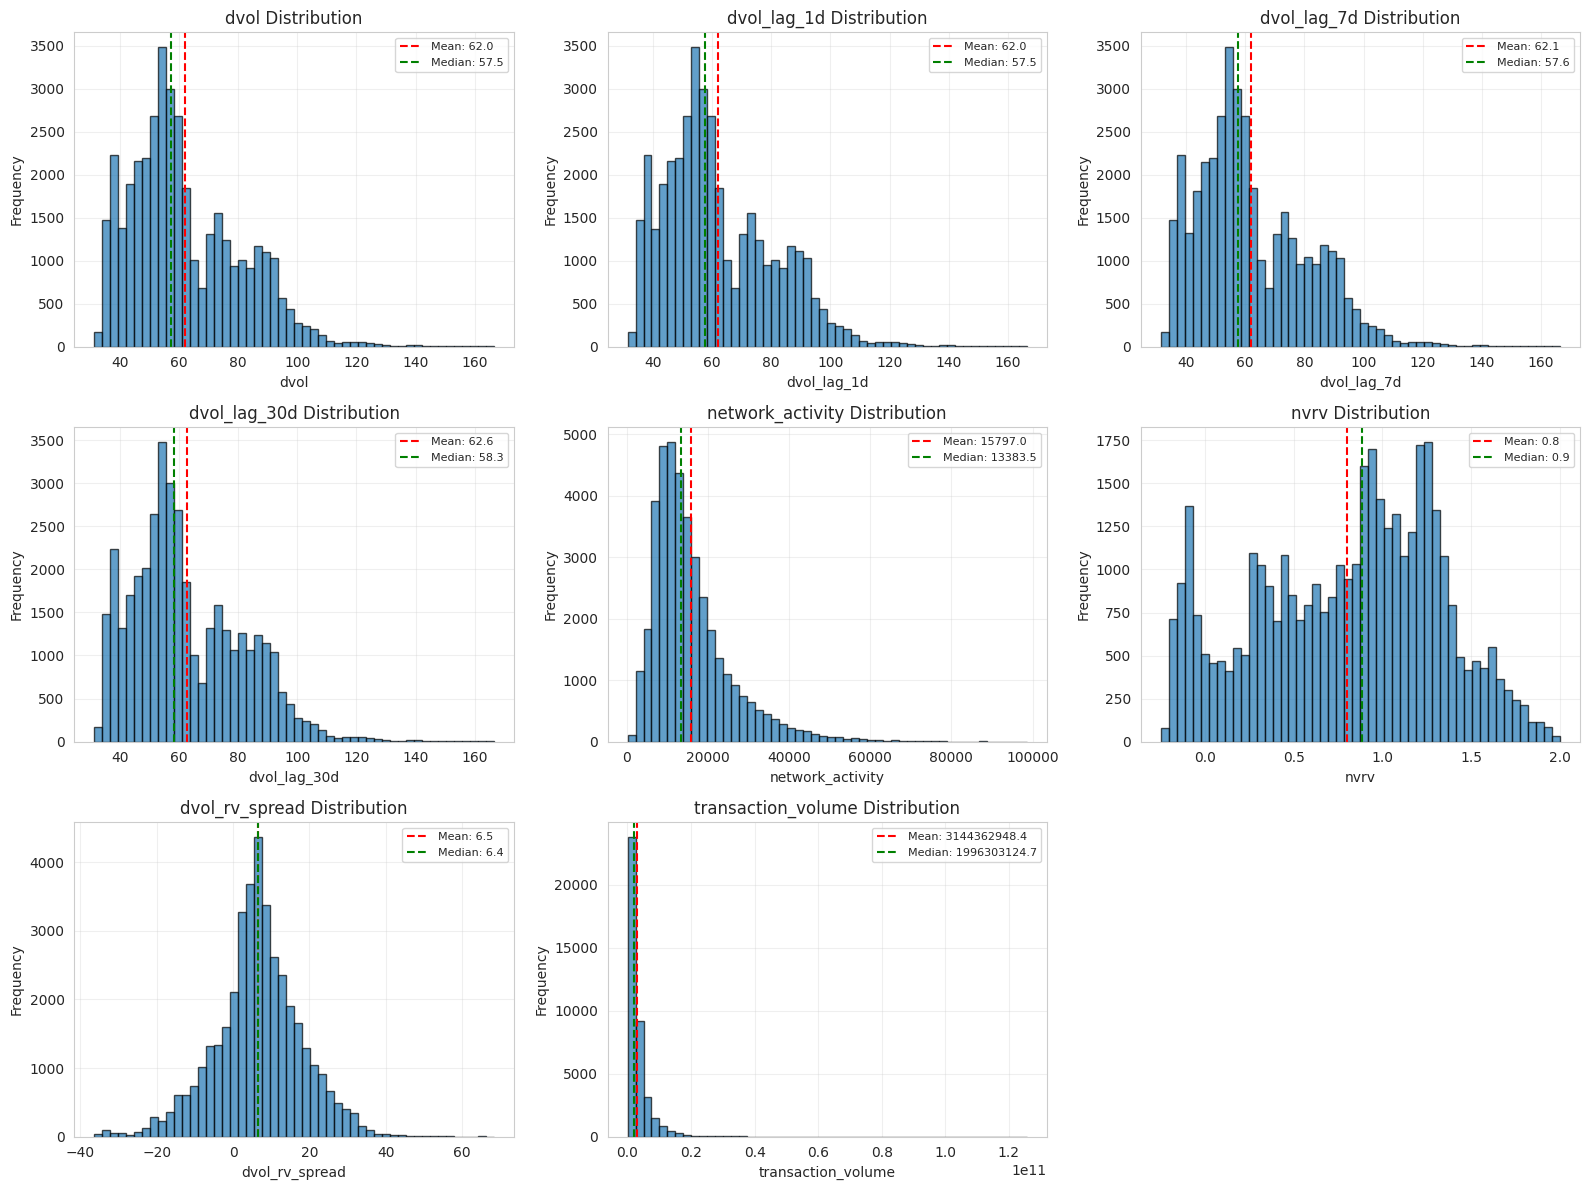

In [13]:
# Get all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate grid dimensions
n_vars = len(numeric_cols)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

# Plot each variable
for ax, col in zip(axes, numeric_cols):
    data = df[col].dropna()
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_val:.1f}")
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f"Median: {median_val:.1f}")
    
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{col} Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused subplots
for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


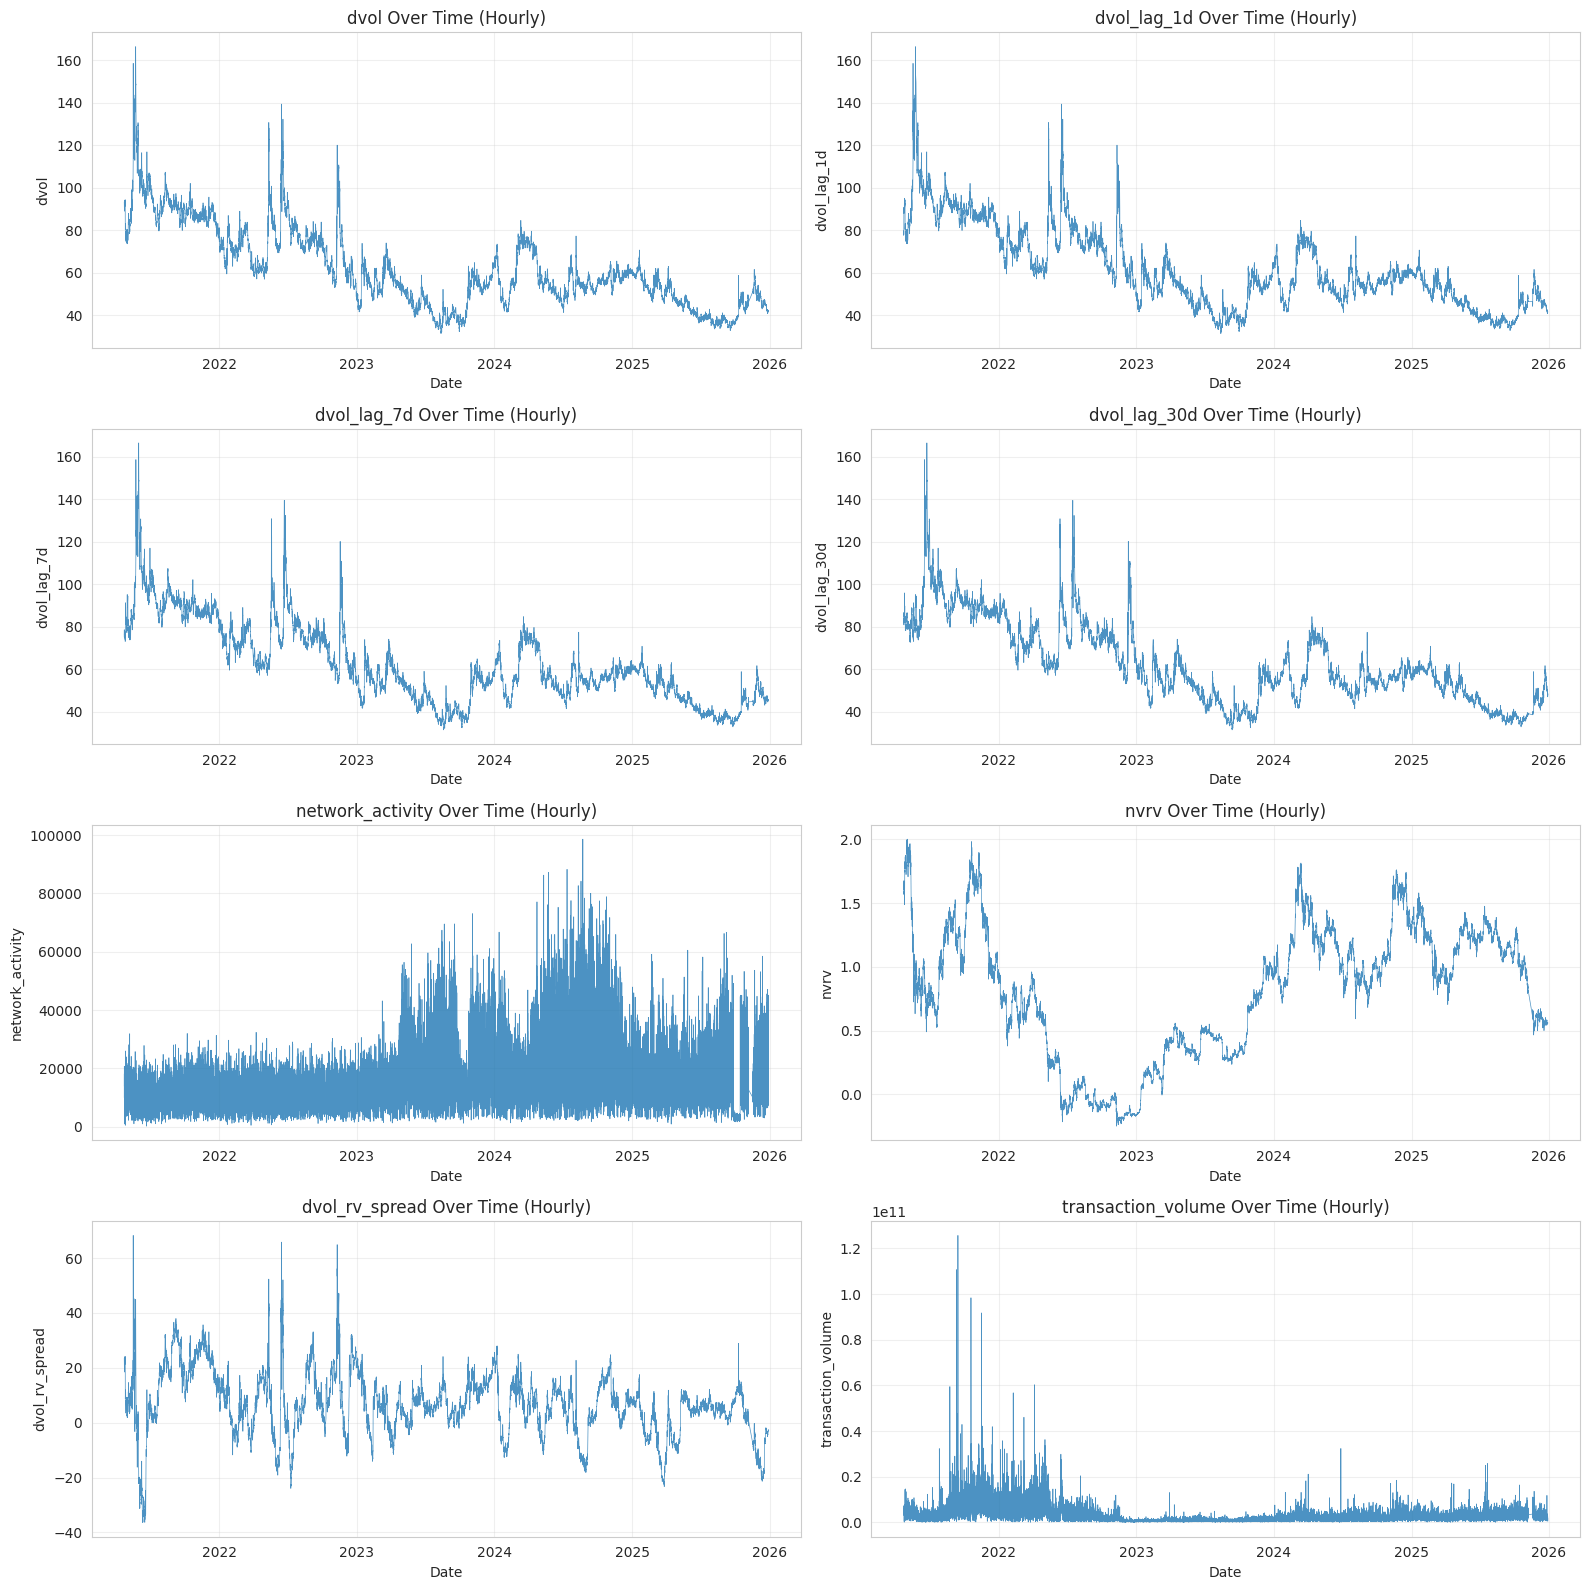

In [17]:
# Get all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate grid dimensions
n_vars = len(numeric_cols)
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

# Plot each variable's time series
for ax, col in zip(axes, numeric_cols):
    ax.plot(df['timestamp'], df[col], linewidth=0.5, alpha=0.8)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.set_title(f'{col} Over Time (Hourly)')
    ax.grid(alpha=0.3)

# Hide unused subplots
for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


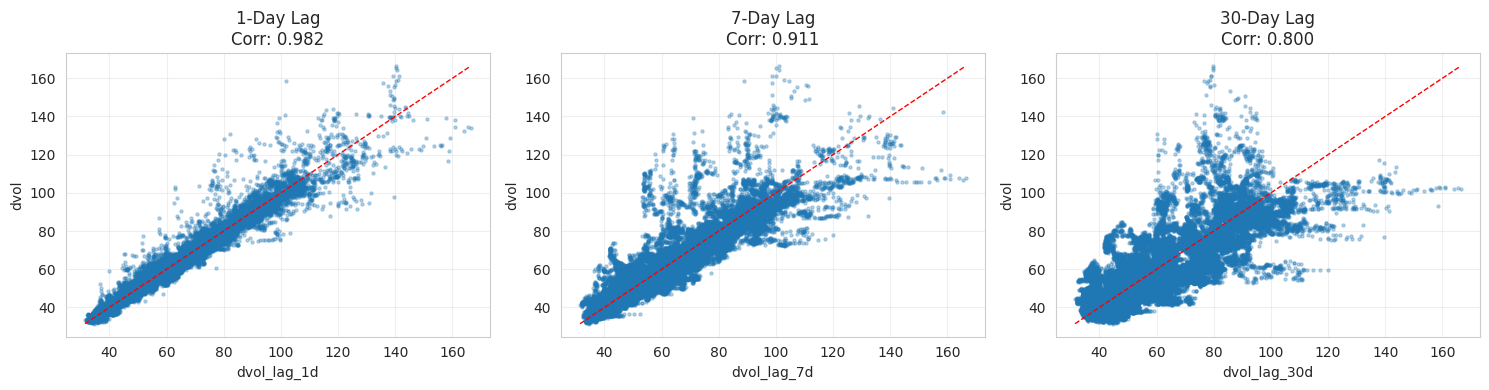

In [23]:
# Scatter plots of current DVOL vs lags
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lags = [('dvol_lag_1d', '1-Day Lag'), ('dvol_lag_7d', '7-Day Lag'), ('dvol_lag_30d', '30-Day Lag')]

for ax, (lag_col, title) in zip(axes, lags):
    ax.scatter(df[lag_col], df['dvol'], alpha=0.3, s=5)
    ax.plot([df[lag_col].min(), df[lag_col].max()], 
            [df['dvol'].min(), df['dvol'].max()], 
            'r--', linewidth=1, label='y=x')
    ax.set_xlabel(lag_col)
    ax.set_ylabel('dvol')
    ax.set_title(f'{title}\nCorr: {df[lag_col].corr(df["dvol"]):.3f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [28]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    """Run Augmented Dickey-Fuller test for stationarity."""
    result = adfuller(series.dropna())
    is_stationary = result[1] < 0.05
    return {
        'name': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary': is_stationary,
        '5% Critical': result[4]['5%']
    }

# Test all numeric variables
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("="*70)
print("AUGMENTED DICKEY-FULLER STATIONARITY TESTS")
print("="*70)

results = []
for col in numeric_cols:
    result = adf_test(df[col], col)
    results.append(result)
    status = "STATIONARY" if result['Stationary'] else "NON-STATIONARY"
    print(f"{result['name']:25s} | ADF: {result['ADF Statistic']:8.4f} | p: {result['p-value']:6.4f} | {status}")

# Summary
print("\n" + "="*70)
print("SUMMARY:")
n_stationary = sum(r['Stationary'] for r in results)
print(f"  Stationary variables: {n_stationary}/{len(results)}")
print(f"  Non-stationary variables: {len(results) - n_stationary}/{len(results)}")
print("="*70)

# Create a summary table
results_df = pd.DataFrame(results)
print("\nDetailed Results:")
print(results_df[['name', 'ADF Statistic', 'p-value', 'Stationary']])


AUGMENTED DICKEY-FULLER STATIONARITY TESTS
dvol                      | ADF:  -3.5013 | p: 0.0080 | STATIONARY
dvol_lag_1d               | ADF:  -3.6128 | p: 0.0055 | STATIONARY
dvol_lag_7d               | ADF:  -3.5428 | p: 0.0070 | STATIONARY
dvol_lag_30d              | ADF:  -3.6113 | p: 0.0055 | STATIONARY
network_activity          | ADF:  -8.1867 | p: 0.0000 | STATIONARY
nvrv                      | ADF:  -2.2566 | p: 0.1864 | NON-STATIONARY
dvol_rv_spread            | ADF:  -6.4465 | p: 0.0000 | STATIONARY
transaction_volume        | ADF:  -9.1927 | p: 0.0000 | STATIONARY
dvol_diff                 | ADF: -28.0485 | p: 0.0000 | STATIONARY

SUMMARY:
  Stationary variables: 8/9
  Non-stationary variables: 1/9

Detailed Results:
                 name  ADF Statistic       p-value  Stationary
0                dvol      -3.501286  7.954134e-03        True
1         dvol_lag_1d      -3.612795  5.521077e-03        True
2         dvol_lag_7d      -3.542837  6.952736e-03        True
3        

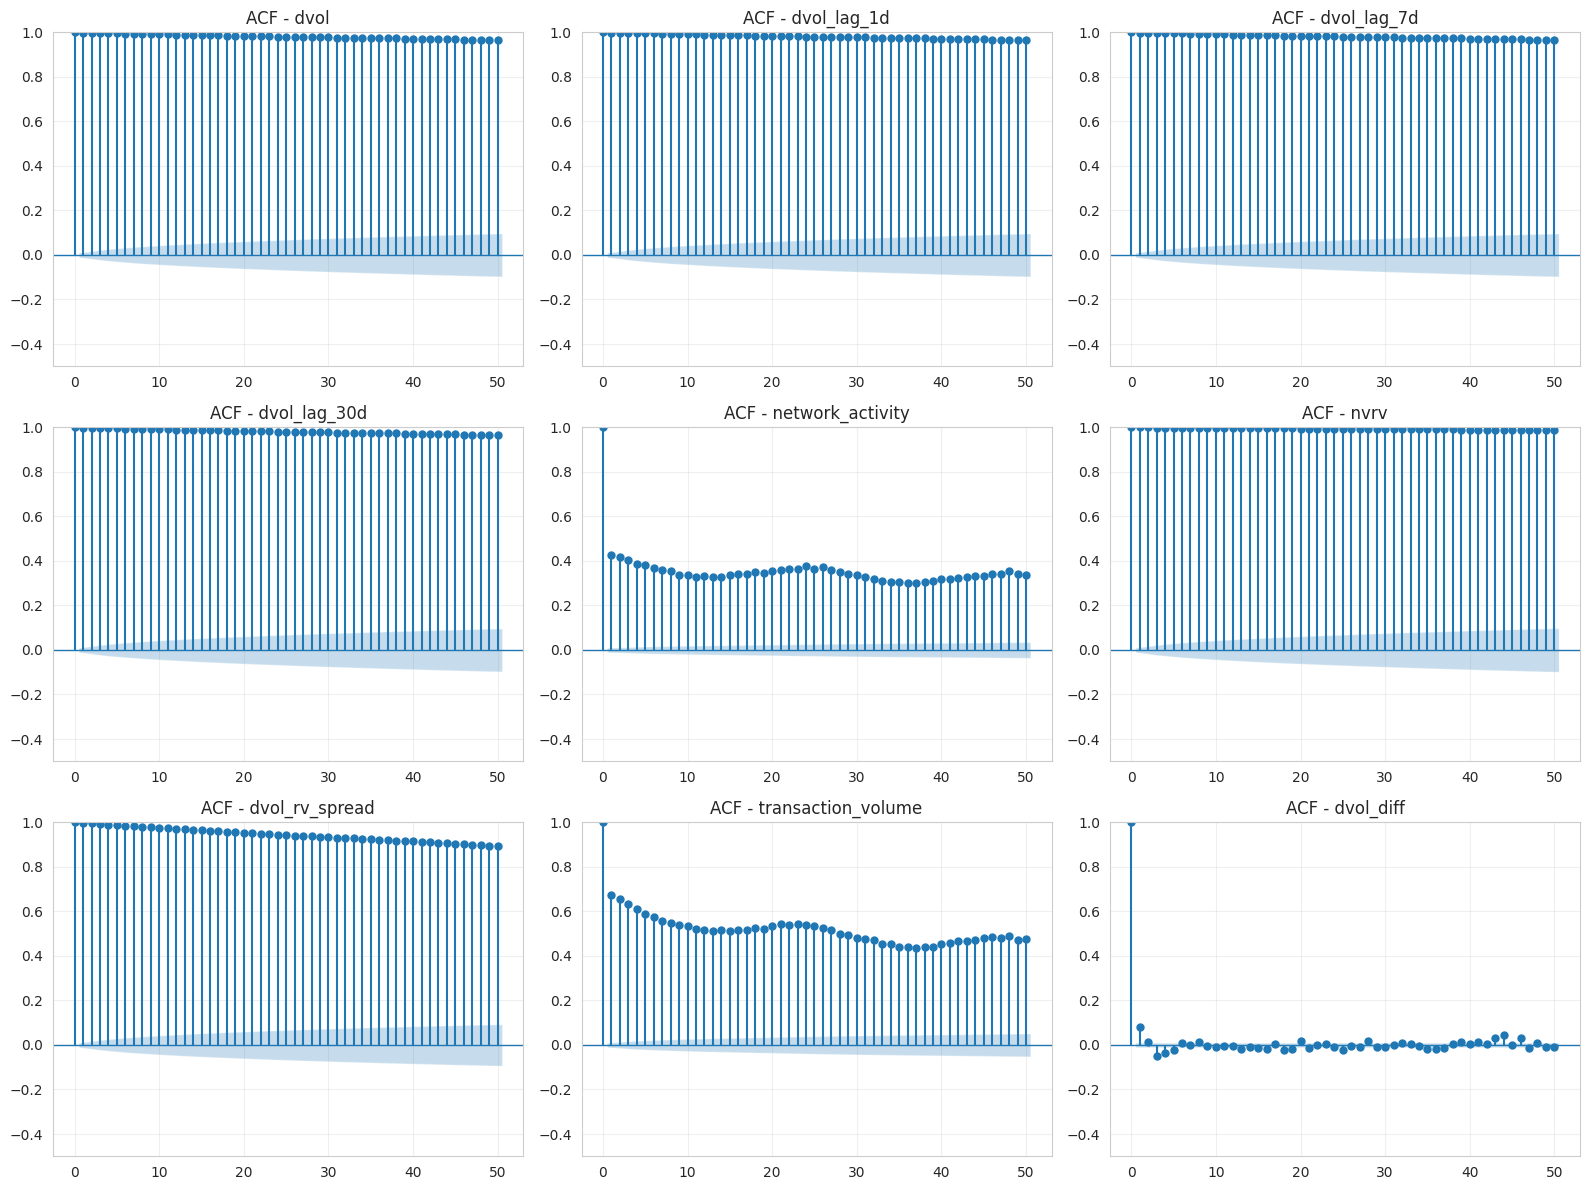

AUTOCORRELATION SUMMARY (Key Lags)
          Variable  Lag-1 AC  Lag-24 AC  Lag-168 AC  Has_Memory
              dvol  0.999216   0.982198    0.910693        True
       dvol_lag_1d  0.999213   0.982145    0.910566        True
       dvol_lag_7d  0.999205   0.981938    0.910220        True
      dvol_lag_30d  0.999202   0.981837    0.910641        True
  network_activity  0.427887   0.375779    0.329671       False
              nvrv  0.999754   0.994537    0.964182        True
    dvol_rv_spread  0.997658   0.945471    0.699481        True
transaction_volume  0.674201   0.540598    0.499463        True
         dvol_diff  0.078754  -0.009363    0.009733       False

INTERPRETATION:
  Lag-1 AC > 0.5: Strong short-term memory (useful for forecasting)
  Lag-24 AC: Daily seasonality pattern
  Lag-168 AC: Weekly seasonality pattern


In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Get all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate grid dimensions for ACF only (more readable)
n_vars = len(numeric_cols)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_vars > 1 else [axes]

# Plot ACF for each variable (50 lags)
for ax, col in zip(axes, numeric_cols):
    plot_acf(df[col].dropna(), ax=ax, lags=50, alpha=0.05, linewidth=1)
    ax.set_title(f'ACF - {col}')
    ax.set_ylim(-0.5, 1.0)
    ax.grid(alpha=0.3)

# Hide unused subplots
for ax in axes[n_vars:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Summary table of key autocorrelations
print("="*70)
print("AUTOCORRELATION SUMMARY (Key Lags)")
print("="*70)

acf_summary = []
for col in numeric_cols:
    series = df[col].dropna()
    # Calculate autocorrelation at specific lags manually
    autocorr_lag1 = series.autocorr(lag=1)
    autocorr_lag24 = series.autocorr(lag=24) if len(series) > 24 else np.nan
    autocorr_lag168 = series.autocorr(lag=168) if len(series) > 168 else np.nan  # 1 week
    
    acf_summary.append({
        'Variable': col,
        'Lag-1 AC': autocorr_lag1,
        'Lag-24 AC': autocorr_lag24,
        'Lag-168 AC': autocorr_lag168,
        'Has_Memory': abs(autocorr_lag1) > 0.5
    })

acf_df = pd.DataFrame(acf_summary)
print(acf_df.to_string(index=False))

print("\n" + "="*70)
print("INTERPRETATION:")
print("  Lag-1 AC > 0.5: Strong short-term memory (useful for forecasting)")
print("  Lag-24 AC: Daily seasonality pattern")
print("  Lag-168 AC: Weekly seasonality pattern")
print("="*70)
